In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [26]:
df = pd.read_csv('titanic_dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [27]:
df.shape

(891, 12)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Q1. Create a Bar Chart to show the survival rate of passengers from each Embarked port.

#### X-axis: Embarked
#### Y-axis: Average of Survived
#### Add proper title and labels.
#### Identify which port has the highest survival rate.

In [29]:
survival_rate = df.groupby("Embarked")["Survived"].mean()

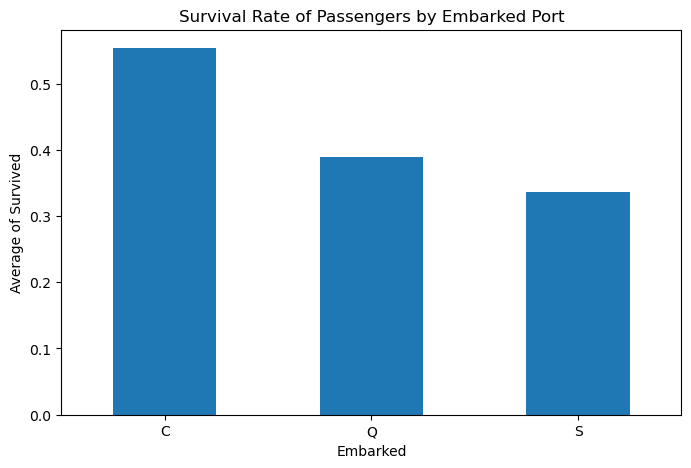

In [31]:
survival_rate.plot(kind="bar", figsize=(8, 5))
plt.title("Survival Rate of Passengers by Embarked Port")
plt.xlabel("Embarked")
plt.ylabel("Average of Survived")
plt.xticks(rotation=0)
plt.show()

### Q2. Create a new column FamilySize using:

#### FamilySize = SibSp + Parch + 1

#### Then create a Count Plot showing the number of passengers for each family-size category.

#### X-axis: FamilySize
#### Y-axis: Number of Passengers
#### Identify the most common family size.

In [39]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

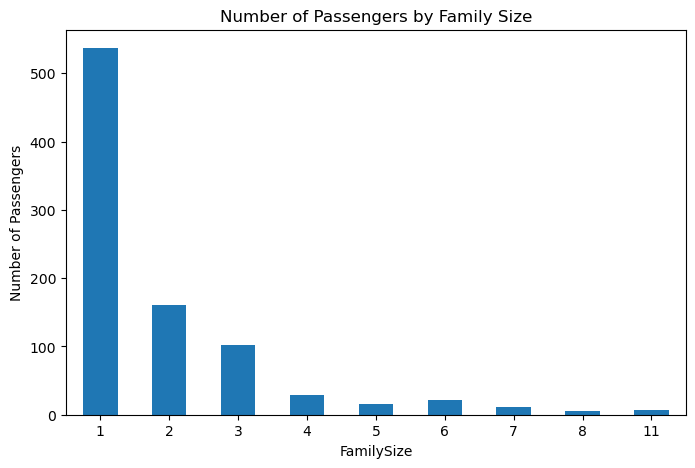

In [40]:
family_size_count = df["FamilySize"].value_counts().sort_index()
family_size_count.plot(kind="bar", figsize=(8, 5))
plt.title("Number of Passengers by Family Size")
plt.xlabel("FamilySize")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.show()

In [36]:
most_common_size = family_size_count.idxmax()
most_common_count = family_size_count.max()
print("Most common family size:", most_common_size)
print("Number of passengers:", most_common_count)

Most common family size: 1
Number of passengers: 537


### Q3. Create a Box Plot to compare Fare across different Pclass, while separating passengers by Sex.

#### X-axis: Pclass
#### Y-axis: Fare
#### Use Sex as hue.
#### Identify which group paid the highest fares.

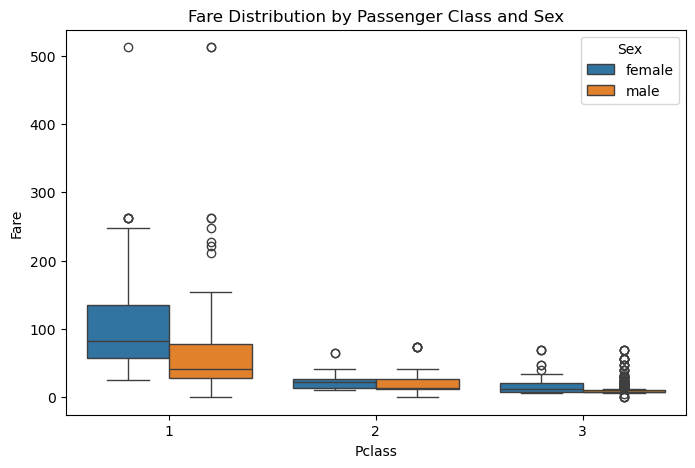

In [43]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Pclass", y="Fare",  hue="Sex")
plt.title("Fare Distribution by Passenger Class and Sex")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()

In [45]:
average_fare = df.groupby(["Pclass", "Sex"])["Fare"].mean()
average_fare

Pclass  Sex   
1       female    106.125798
        male       67.226127
2       female     21.970121
        male       19.741782
3       female     16.118810
        male       12.661633
Name: Fare, dtype: float64

In [46]:
highest_group = average_fare.idxmax()
highest_fare = average_fare.max()
print("\nGroup with the highest average fare:", highest_group)
print("Highest average fare:", round(highest_fare, 2))


Group with the highest average fare: (np.int64(1), 'female')
Highest average fare: 106.13


### Q4. Using the FamilySize column created in Q2, create a Line Plot showing the average survival rate for each family size.

#### X-axis: FamilySize
#### Y-axis: Survival Rate
#### Add markers to the line.
#### Identify the family size with the highest survival rate.

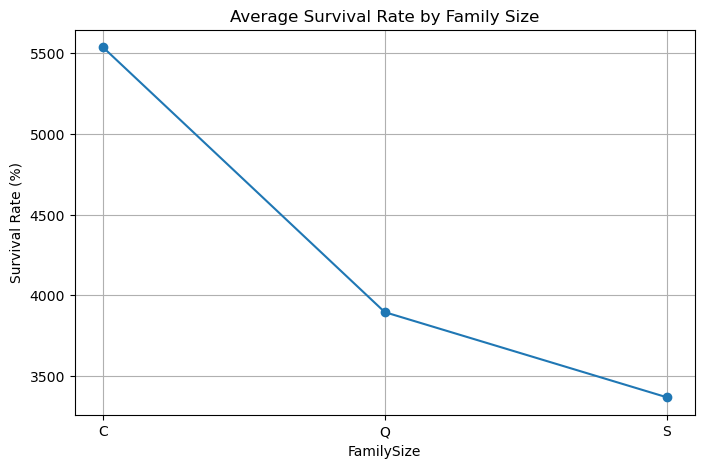

In [48]:
survival_rate = survival_rate * 100

plt.figure(figsize=(8, 5))
plt.plot(survival_rate.index, survival_rate.values, marker="o")
plt.title("Average Survival Rate by Family Size")
plt.xlabel("FamilySize")
plt.ylabel("Survival Rate (%)")
plt.grid(True)
plt.show()

In [49]:
highest_family_size = survival_rate.idxmax()
highest_survival_rate = survival_rate.max()

print("Family size with the highest survival rate:", highest_family_size)
print("Highest survival rate:", round(highest_survival_rate * 100, 2), "%")

Family size with the highest survival rate: C
Highest survival rate: 553571.43 %


### Q5.Passenger Class & Gender Survival Comparison
#### Create a stacked bar chart showing the number of Survived and Not Survived passengers for each combination of Pclass and Sex.

In [50]:
df["Survival_Status"] = df["Survived"].map({1: "Survived",0: "Not Survived"})
survival_count = pd.crosstab([df["Pclass"], df["Sex"]], df["Survival_Status"])

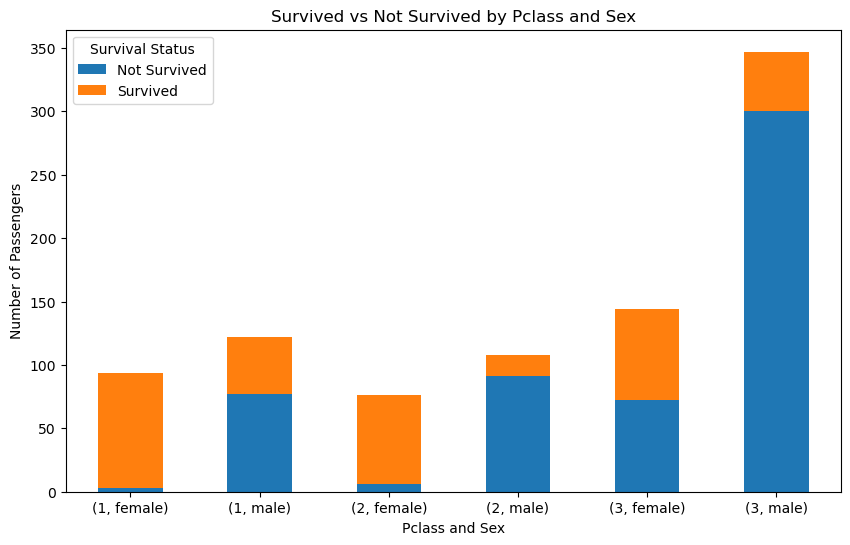

In [51]:
survival_count.plot( kind="bar", stacked=True, figsize=(10, 6))
plt.title("Survived vs Not Survived by Pclass and Sex")
plt.xlabel("Pclass and Sex")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.legend(title="Survival Status")
plt.show()